In [5]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv    
load_dotenv()

from src.sdlc_system.state.state_file import  SDLCState , UserStoryList


from src.sdlc_system.graph.build_graph import GraphBuilder
from src.sdlc_system.graph.graph_executor import GraphExecutor

import os

In [ ]:
# from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="openai/gpt-oss-20b"
)

# response = llm.invoke("Say hello in one line")

# print(response.content)

In [6]:
llm = ChatGroq(model = 'openai/gpt-oss-20b')

In [9]:
llm.invoke("India Capital")

AIMessage(content='The capital of India is **New\u202fDelhi**.', additional_kwargs={'reasoning_content': 'The user says "India Capital". They probably want the capital of India. The capital of India is New Delhi. Provide that.'}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 73, 'total_tokens': 120, 'completion_time': 0.050323377, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.003604049, 'prompt_tokens_details': None, 'queue_time': 0.041526466, 'total_time': 0.053927426}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_80501ff3a1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d7634-9b09-7ef0-81af-8db796b2ec4e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 47, 'total_tokens': 120, 'output_token_details': {'reasoning': 27}})

# Graph

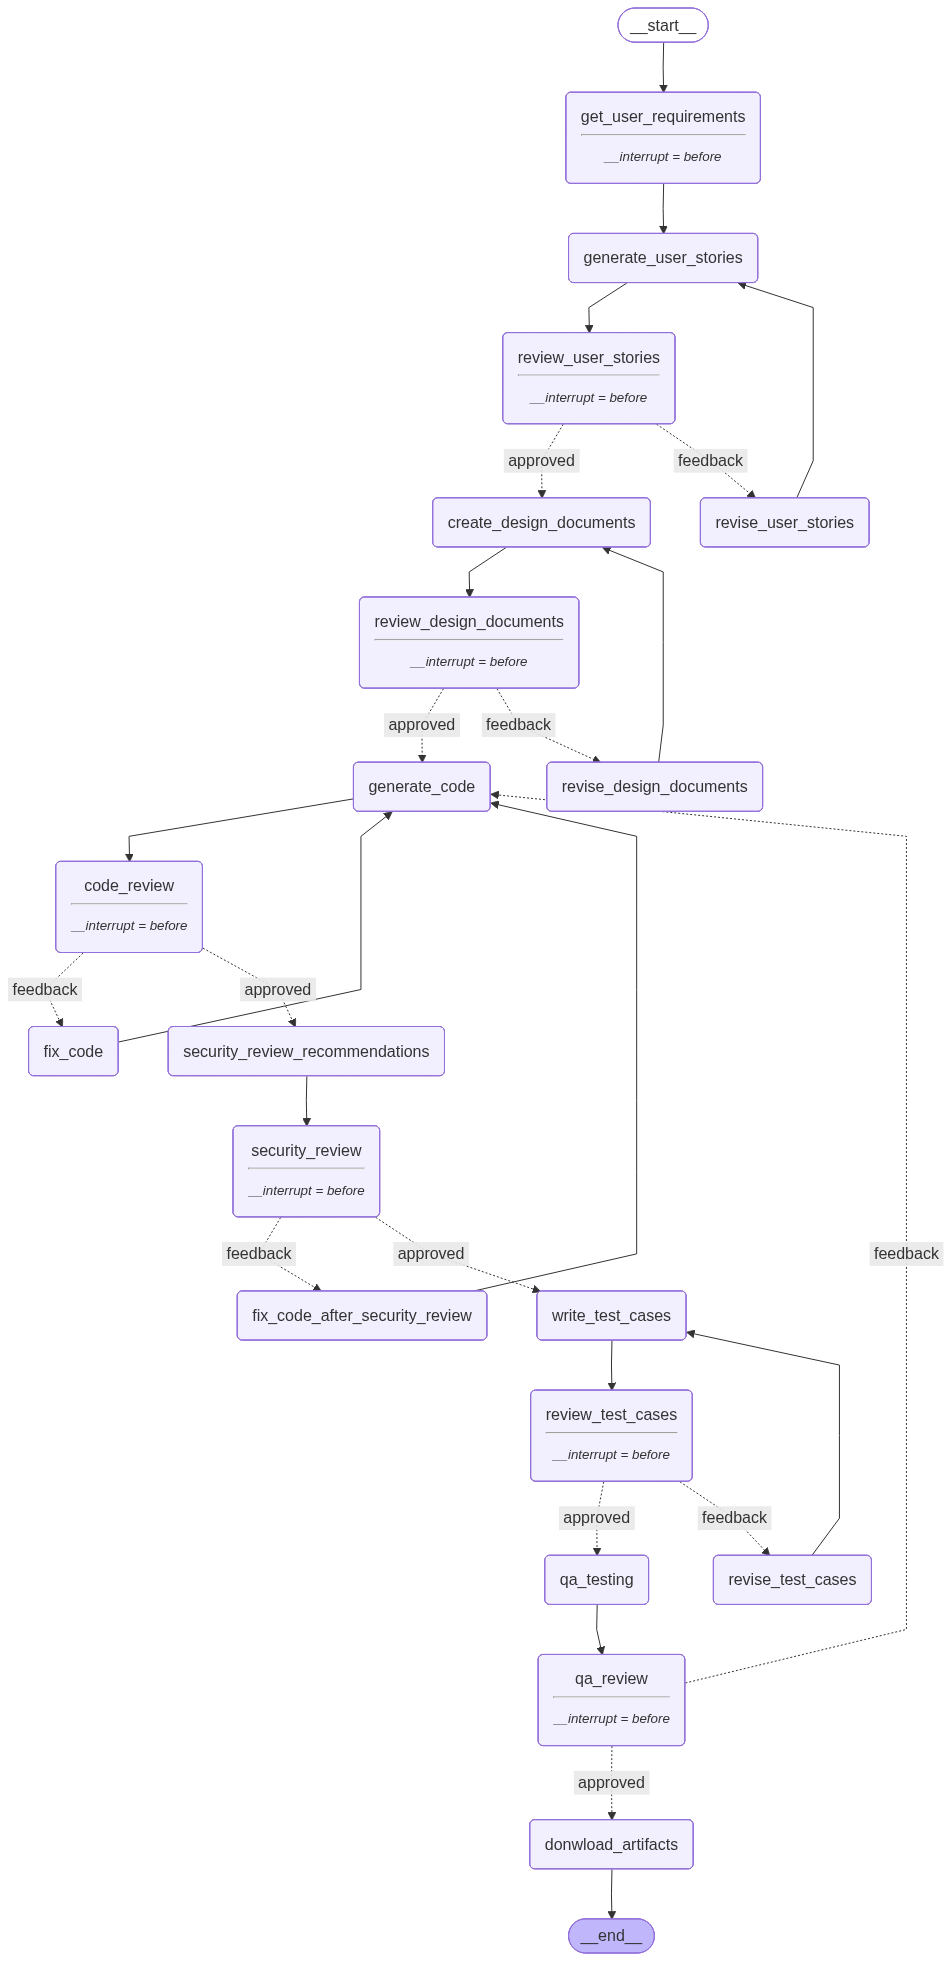

In [10]:
graph_builder = GraphBuilder(llm)
graph = graph_builder.setup_graph()

graph

In [11]:
graph_executor = GraphExecutor(graph)

In [12]:
# Step 1: Start with just the Project Name
project_name = "Food Delivery App"
start_response = graph_executor.start_workflow(project_name)

task_id = start_response["task_id"]
print(f"Workflow started with Task ID: {task_id}")

Workflow started with Task ID: sdlc-session-8424577b


In [13]:
# Step 2: Pass requirements later using the task_id
requirements = [
    "User can order food",
    "User can track order",
    "User can make payments"
]
final_response = graph_executor.generate_stories(task_id, requirements)

Deserializing unregistered type src.sdlc_system.state.state_file.UserStoryList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('src.sdlc_system.state.state_file', 'UserStoryList')]


In [14]:
final_response

{'task_id': 'sdlc-session-8424577b',
 'state': {'next_node': 'review_user_stories',
  'project_name': 'Food Delivery App',
  'requirements': ['User can order food',
   'User can track order',
   'User can make payments'],
  'user_stories': UserStoryList(user_stories=[UserStories(id='US-001', title='Order Food', description='As a user, I want to order food from the app so that I can have my favorite meals delivered to my location.', priority=1, acceptance_criteria='1. User can browse restaurants and menu items.\n2. User can add items to a cart.\n3. User can review cart items, change quantities, and remove items.\n4. User can submit the order and receive a confirmation with an estimated delivery time.'), UserStories(id='US-002', title='Track Order', description='As a user, I want to track my order status so that I know when it will arrive.', priority=1, acceptance_criteria='1. User can view the current status of the order (e.g., Received, Preparing, Out for delivery, Delivered).\n2. User

In [15]:
print(final_response['state']['user_stories'])

user_stories=[UserStories(id='US-001', title='Order Food', description='As a user, I want to order food from the app so that I can have my favorite meals delivered to my location.', priority=1, acceptance_criteria='1. User can browse restaurants and menu items.\n2. User can add items to a cart.\n3. User can review cart items, change quantities, and remove items.\n4. User can submit the order and receive a confirmation with an estimated delivery time.'), UserStories(id='US-002', title='Track Order', description='As a user, I want to track my order status so that I know when it will arrive.', priority=1, acceptance_criteria='1. User can view the current status of the order (e.g., Received, Preparing, Out for delivery, Delivered).\n2. User can see an estimated time of arrival.\n3. User receives push notifications for status changes.'), UserStories(id='US-003', title='Make Payments', description='As a user, I want to pay for my order through the app so that I can complete the transaction s

In [16]:
final_response['state']['user_stories'].user_stories

[UserStories(id='US-001', title='Order Food', description='As a user, I want to order food from the app so that I can have my favorite meals delivered to my location.', priority=1, acceptance_criteria='1. User can browse restaurants and menu items.\n2. User can add items to a cart.\n3. User can review cart items, change quantities, and remove items.\n4. User can submit the order and receive a confirmation with an estimated delivery time.'),
 UserStories(id='US-002', title='Track Order', description='As a user, I want to track my order status so that I know when it will arrive.', priority=1, acceptance_criteria='1. User can view the current status of the order (e.g., Received, Preparing, Out for delivery, Delivered).\n2. User can see an estimated time of arrival.\n3. User receives push notifications for status changes.'),
 UserStories(id='US-003', title='Make Payments', description='As a user, I want to pay for my order through the app so that I can complete the transaction securely.', 

In [ ]:
# Provide "approved" status to move the graph to END
approval_response = graph_executor.graph_review_flow(
    task_id=task_id, 
    status="approved", 
    feedback="", 
    review_type="review_user_stories"
)

print("Workflow Status:", approval_response['state']['next_node'] if approval_response['state'].get('next_node') else "Finished")

In [10]:
# Provide feedback to trigger a revision loop
feedback_response = graph_executor.graph_review_flow(
    task_id=task_id, 
    status="feedback", 
    feedback="Add one more user story", 
    review_type="review_user_stories"
)

# Display the newly regenerated stories
feedback_response['state']['user_stories'].user_stories

Deserializing unregistered type src.sdlc_system.state.state_file.UserStoryList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('src.sdlc_system.state.state_file', 'UserStoryList')]
Deserializing unregistered type src.sdlc_system.state.state_file.UserStoryList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('src.sdlc_system.state.state_file', 'UserStoryList')]


[UserStories(id='US-001', title='Order Food', description='As a user, I want to be able to order food from the app so that I can receive meals conveniently.', priority=1, acceptance_criteria='- User can browse menu items\n- User can add items to cart\n- User can review cart\n- User can place order and receive confirmation'),
 UserStories(id='US-002', title='Track Order', description='As a user, I want to track my order status so that I know when it will arrive.', priority=2, acceptance_criteria='- Order status updates in real time\n- User receives notifications on status changes\n- User can view ETA'),
 UserStories(id='US-003', title='Make Payments', description='As a user, I want to make payments within the app so that I can pay for my food quickly and securely.', priority=3, acceptance_criteria='- User can add and manage payment methods\n- Payment gateway integration\n- Confirmation of payment received'),
 UserStories(id='US-004', title='Rate and Review Order', description='As a user

In [14]:
# See what the manual tracker says
feedback_response['state']

{'next_node': 'review_user_stories',
 'project_name': 'Food Delivery App',
 'requirements': ['User can order food',
  'User can track order',
  'User can make payments'],
 'user_stories': UserStoryList(user_stories=[UserStories(id='US-001', title='Order Food', description='As a user, I want to be able to order food from the app so that I can receive meals conveniently.', priority=1, acceptance_criteria='- User can browse menu items\n- User can add items to cart\n- User can review cart\n- User can place order and receive confirmation'), UserStories(id='US-002', title='Track Order', description='As a user, I want to track my order status so that I know when it will arrive.', priority=2, acceptance_criteria='- Order status updates in real time\n- User receives notifications on status changes\n- User can view ETA'), UserStories(id='US-003', title='Make Payments', description='As a user, I want to make payments within the app so that I can pay for my food quickly and securely.', priority=3,

In [15]:
approval_response = graph_executor.graph_review_flow(
    task_id=task_id, 
    status="approved", 
    feedback="", 
    review_type="review_user_stories"
)

print("Workflow Status:", approval_response['state']['next_node'] if approval_response['state'].get('next_node') else "Finished")

Deserializing unregistered type src.sdlc_system.state.state_file.UserStoryList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('src.sdlc_system.state.state_file', 'UserStoryList')]


Workflow Status: END


In [16]:
approval_response

{'task_id': 'sdlc-session-9089f30d',
 'state': {'next_node': 'END',
  'project_name': 'Food Delivery App',
  'requirements': ['User can order food',
   'User can track order',
   'User can make payments'],
  'user_stories': {'user_stories': [{'id': 'US-001',
     'title': 'Order Food',
     'description': 'As a user, I want to be able to order food from the app so that I can receive meals conveniently.',
     'priority': 1,
     'acceptance_criteria': '- User can browse menu items\n- User can add items to cart\n- User can review cart\n- User can place order and receive confirmation'},
    {'id': 'US-002',
     'title': 'Track Order',
     'description': 'As a user, I want to track my order status so that I know when it will arrive.',
     'priority': 2,
     'acceptance_criteria': '- Order status updates in real time\n- User receives notifications on status changes\n- User can view ETA'},
    {'id': 'US-003',
     'title': 'Make Payments',
     'description': 'As a user, I want to make